In [3]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
!pip install -q tensorflow keras nltk scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, time, warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Keras / TF
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D, Bidirectional,
    LSTM, GRU, Dense, Dropout, GlobalMaxPooling1D,
    GlobalAveragePooling1D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✅ All imports successful')

TensorFlow  : 2.20.0
GPU available: True
✅ All imports successful


In [4]:
# ── Cell 2: Load Data ──────────────────────────────────────────────────────
# Mount Drive or upload manually:
# from google.colab import files; files.upload()

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

train['comment_text'] = train['comment_text'].fillna('unknown')
test['comment_text']  = test['comment_text'].fillna('unknown')

print(f'Train : {train.shape} | Test : {test.shape}')
train[LABELS].sum()

Train : (16000, 8) | Test : (4000, 2)


,0
toxic,1533
severe_toxic,159
obscene,847
threat,46
insult,789
identity_hate,142


In [5]:
# ── Cell 3: Text Preprocessing (NLTK) ─────────────────────────────────────
# Deeper than Phase 1 — we now lemmatize and clean more aggressively
# NOTE: We keep stopwords intentionally for LSTM since sequence context matters

lemmatizer = WordNetLemmatizer()
STOP = set(stopwords.words('english'))

# Contraction map for expanding short forms
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'ve": " have", "'m": " am"
}

def expand_contractions(text):
    for pattern, replacement in CONTRACTIONS.items():
        text = text.replace(pattern, replacement)
    return text

def preprocess_lstm(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)   # URLs
    text = re.sub(r'\d+', ' num ', text)                      # numbers → token
    text = re.sub(r'[^\w\s]', ' ', text)                      # punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    # Lemmatize each token (skip stopwords removal — LSTM needs sequence!)
    tokens = [lemmatizer.lemmatize(w) for w in text.split()]
    return ' '.join(tokens)

print('Preprocessing train...')
train['clean_text'] = train['comment_text'].apply(preprocess_lstm)
print('Preprocessing test...')
test['clean_text']  = test['comment_text'].apply(preprocess_lstm)

print('\nBefore:', train['comment_text'].iloc[1][:120])
print('After :', train['clean_text'].iloc[1][:120])

Preprocessing train...
Preprocessing test...

Before: Obama's father was muslim this is a proven fact.  His father was born in the arab part of Africa another fact.  Obama wa
After : obama is father wa muslim this is a proven fact his father wa born in the arab part of africa another fact obama wa neve


In [6]:
# ── Cell 4: Tokenization & Padding ────────────────────────────────────────
MAX_VOCAB  = 50_000   # top N most frequent words
MAX_LEN    = 200      # max sequence length (covers ~95% of comments)
EMBED_DIM  = 128      # embedding dimension (since GloVe is removed)

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train['clean_text'])
X_test_seq  = tokenizer.texts_to_sequences(test['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

y_train = train[LABELS].values.astype(np.float32)

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Vocab size     : {vocab_size:,}')
print(f'Train shape    : {X_train_pad.shape}')
print(f'Test shape     : {X_test_pad.shape}')

# Sequence length coverage
lengths = [len(s) for s in X_train_seq]
print(f'\nSeq len — mean: {np.mean(lengths):.0f}, p95: {np.percentile(lengths,95):.0f}, max: {max(lengths)}')
print(f'MAX_LEN={MAX_LEN} covers {np.mean([l <= MAX_LEN for l in lengths])*100:.1f}% of comments')

Vocab size     : 41,018
Train shape    : (16000, 200)
Test shape     : (4000, 200)

Seq len — mean: 69, p95: 240, max: 1250
MAX_LEN=200 covers 93.3% of comments


In [7]:
# ── Cell 6: Train/Val Split ────────────────────────────────────────────────
indices = np.arange(len(X_train_pad))
X_tr, X_val, y_tr, y_val, idx_tr, idx_val = train_test_split(
    X_train_pad, y_train, indices, test_size=0.1, random_state=42
)
print(f'Train: {X_tr.shape[0]:,} | Val: {X_val.shape[0]:,}')

Train: 14,400 | Val: 1,600


In [8]:
# ── Cell 7: Class Weights for Imbalance ───────────────────────────────────
# Compute class weights for model.fit()
total_pos = y_tr.sum()
total_neg = y_tr.size - total_pos
pos_weight = total_neg / (total_pos + 1e-6)

class_weight = {0: 1.0, 1: pos_weight}
print(f"Overall positive class weight: {pos_weight:.2f}x")
print(f"class_weight dictionary: {class_weight}")

Overall positive class weight: 26.45x
class_weight dictionary: {0: 1.0, 1: np.float32(26.45472)}


In [9]:
# ── Cell 8: Build BiLSTM Model ─────────────────────────────────────────────
# Architecture: Embedding → SpatialDropout → BiLSTM → BiGRU
#               → GlobalMax + GlobalAvg Pool → Concat → Dense → Output

def build_bilstm(vocab_size, embed_dim, max_len, lstm_units=128, gru_units=64, dropout=0.3):

    inp = Input(shape=(max_len,), name='input')

    # Embedding layer
    x = Embedding(vocab_size, embed_dim,
                  embeddings_initializer='uniform',
                  name='random_embedding')(inp)

    x = SpatialDropout1D(dropout)(x)

    # Bidirectional LSTM — reads sequence both ways
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, recurrent_dropout=0.1),
        name='bilstm'
    )(x)

    # Stacked Bidirectional GRU — lighter, captures higher-level patterns
    x = Bidirectional(
        GRU(gru_units, return_sequences=True, recurrent_dropout=0.1),
        name='bigru'
    )(x)

    # Dual pooling — max captures strongest signal, avg captures overall tone
    avg_pool = GlobalAveragePooling1D(name='avg_pool')(x)
    max_pool = GlobalMaxPooling1D(name='max_pool')(x)
    x = Concatenate(name='concat_pool')([avg_pool, max_pool])

    x = Dense(128, activation='relu', name='dense_1')(x)
    x = Dropout(dropout)(x)
    out = Dense(6, activation='sigmoid', name='output')(x)  # 6 labels, sigmoid per label

    model = Model(inputs=inp, outputs=out)
    return model

model = build_bilstm(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_embedding    │ (None, 200, 128)  │  5,250,304 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 200, 128)  │          0 │ random_embedding… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 200, 256)  │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bigru               │ (None, 200, 128)  │    123,648 │ bilstm[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 128)       │          0 │ bigru[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 128)       │          0 │ bigru[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_pool         │ (None, 256)       │          0 │ avg_pool[0][0],   │
│ (Concatenate)       │                   │            │ max_pool[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ concat_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 6)         │        774 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,670,790 (21.63 MB)

 Trainable params: 5,670,790 (21.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ── Cell 9: Compile Model ──────────────────────────────────────────────────
# Custom ROC-AUC metric (mean across labels)
class MeanAUC(tf.keras.metrics.AUC):
    def __init__(self, **kwargs):
        super().__init__(multi_label=True, num_labels=6, name='mean_auc', **kwargs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[MeanAUC()]
)
print('✅ Model compiled')

✅ Model compiled


In [11]:
# ── Cell 10: Callbacks ─────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_mean_auc',
        patience=3,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_mean_auc',
        factor=0.5,
        patience=2,
        mode='max',
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_bilstm.keras',
        monitor='val_mean_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]
print('✅ Callbacks ready')

✅ Callbacks ready


In [12]:
# ── Cell 11: Train ─────────────────────────────────────────────────────────
BATCH_SIZE = 256   # good balance for T4 GPU
EPOCHS     = 20    # EarlyStopping will halt before this

print(f'Training BiLSTM-GRU on {X_tr.shape[0]:,} samples...')
start = time.time()

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

elapsed = time.time() - start
print(f'\n⏱️  Training time: {elapsed/60:.1f} min')

Training BiLSTM-GRU on 14,400 samples...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.2843 - mean_auc: 0.4995
Epoch 1: val_mean_auc improved from None to 0.60128, saving model to best_bilstm.keras

Epoch 1: finished saving model to best_bilstm.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - loss: 0.1943 - mean_auc: 0.4901 - val_loss: 0.1459 - val_mean_auc: 0.6013 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1461 - mean_auc: 0.5207
Epoch 2: val_mean_auc improved from 0.60128 to 0.60873, saving model to best_bilstm.keras

Epoch 2: finished saving model to best_bilstm.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - loss: 0.1453 - mean_auc: 0.5347 - val_loss: 0.1424 - val_mean_auc: 0.6087 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.1416 - mean_auc: 0.5833
Epoch 3: val_mean_auc improved from 0.60873 to 0.81595, saving model to best_bilstm.keras

Epoch 3: finished saving model to best_bilstm.keras
57/5

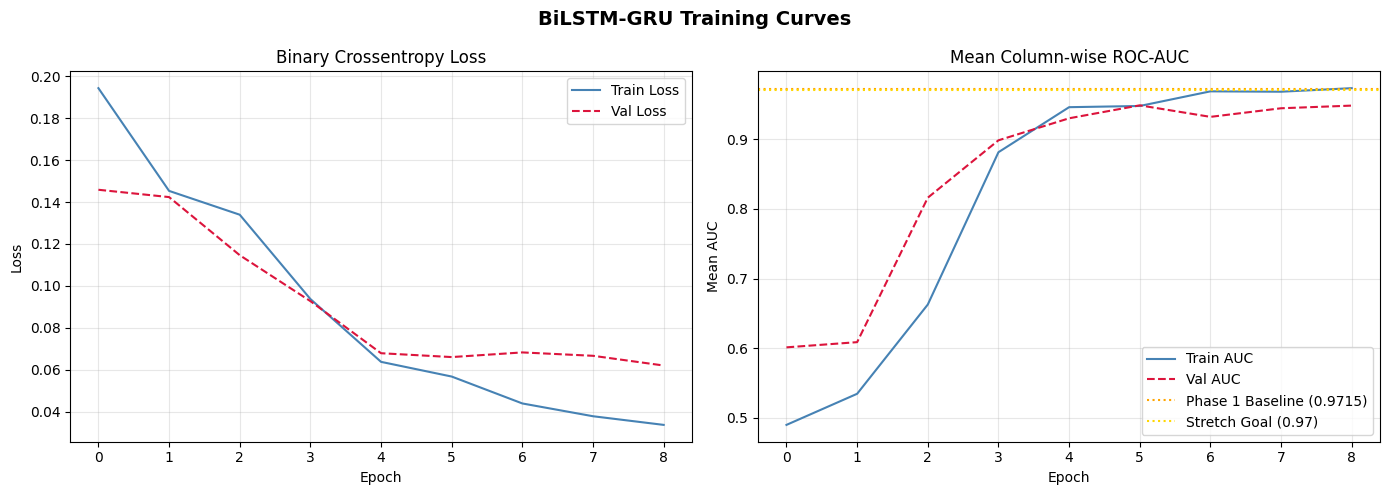

In [13]:
# ── Cell 12: Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BiLSTM-GRU Training Curves', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='crimson', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Binary Crossentropy Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(history.history['mean_auc'],     label='Train AUC', color='steelblue')
axes[1].plot(history.history['val_mean_auc'], label='Val AUC',   color='crimson', linestyle='--')
axes[1].axhline(0.9449, color='orange', linestyle=':', label='Phase 1 Baseline (0.9449)')
axes[1].axhline(0.97,   color='gold',   linestyle=':', label='Stretch Goal (0.97)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC')
axes[1].set_title('Mean Column-wise ROC-AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── Cell 13: Per-class Evaluation ─────────────────────────────────────────
val_preds = model.predict(X_val, batch_size=512, verbose=0)

results = []
for i, label in enumerate(LABELS):
    auc = roc_auc_score(y_val[:, i], val_preds[:, i])
    preds_bin = (val_preds[:, i] >= 0.5).astype(int)
    f1  = f1_score(y_val[:, i], preds_bin, zero_division=0)
    results.append({'Label': label, 'ROC-AUC': round(auc, 4), 'F1': round(f1, 4)})

results_df = pd.DataFrame(results)
mean_auc = results_df['ROC-AUC'].mean()
mean_f1  = results_df['F1'].mean()
results_df.loc[len(results_df)] = ['MEAN', round(mean_auc, 4), round(mean_f1, 4)]

print(results_df.to_string(index=False))
print(f'\n🎯 Mean Column-wise ROC-AUC : {mean_auc:.4f}')
print(f'🎯 Mean F1-Score             : {mean_f1:.4f}')

# Compare to baseline
PHASE1_AUC = 0.9449
delta = mean_auc - PHASE1_AUC
print(f'\n📊 vs Phase 1 Baseline : {delta:+.4f} ({"✅ IMPROVED" if delta > 0 else "⚠️ REGRESSED"})')

        Label  ROC-AUC     F1
        toxic   0.9448 0.7118
 severe_toxic   0.9885 0.3333
      obscene   0.9831 0.7135
       threat   0.9306 0.0000
       insult   0.9743 0.6995
identity_hate   0.9012 0.0000
         MEAN   0.9538 0.4097

🎯 Mean Column-wise ROC-AUC : 0.9537
🎯 Mean F1-Score             : 0.4097

📊 vs Phase 1 Baseline : -0.0178 (⚠️ REGRESSED)


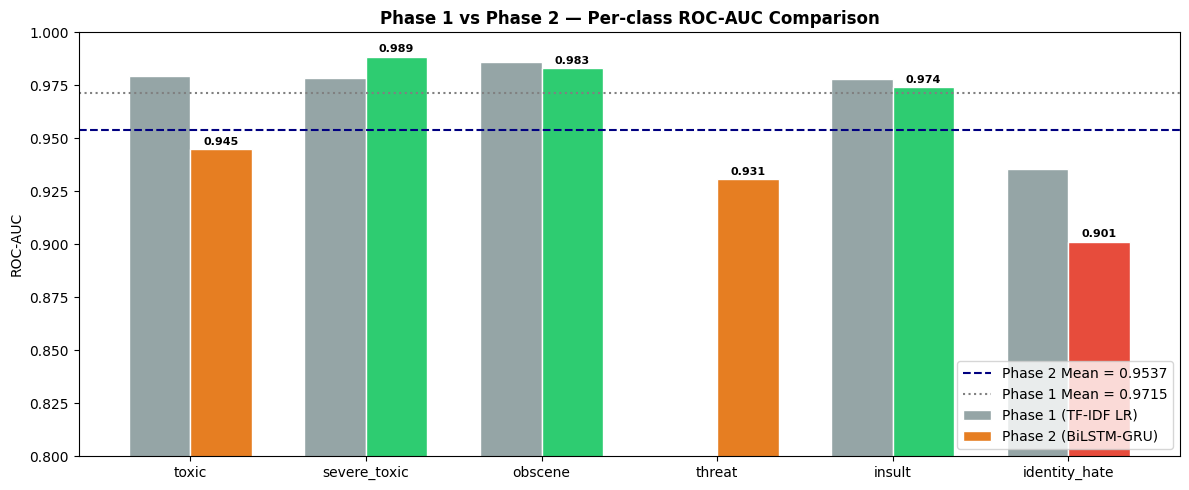

In [15]:
# ── Cell 14: Per-class AUC Bar Chart ──────────────────────────────────────
plot_df = results_df[results_df['Label'] != 'MEAN'].copy()
phase1  = {'toxic':0.9654,'severe_toxic':0.9349,'obscene':0.9755,
           'threat':0.9083,'insult':0.9552,'identity_hate':0.9302}

x = np.arange(len(LABELS))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
p1_vals = [phase1.get(l, 0) or 0 for l in LABELS]
p2_vals = list(plot_df['ROC-AUC'])

bars1 = ax.bar(x - w/2, p1_vals, w, label='Phase 1 (TF-IDF LR)', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x + w/2, p2_vals, w, label='Phase 2 (BiLSTM-GRU)',
               color=['#2ecc71' if v >= 0.97 else '#e67e22' if v >= 0.93 else '#e74c3c'
                      for v in p2_vals], edgecolor='white')

ax.axhline(mean_auc, color='navy', linestyle='--', label=f'Phase 2 Mean = {mean_auc:.4f}')
ax.axhline(0.9449,   color='gray', linestyle=':',  label='Phase 1 Mean = 0.9449')
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylim(0.80, 1.0); ax.set_ylabel('ROC-AUC')
ax.set_title('Phase 1 vs Phase 2 — Per-class ROC-AUC Comparison', fontweight='bold')

for bar, val in zip(bars2, p2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
# ── Cell 15: Error Analysis — Hard Examples ────────────────────────────────
# Find comments the model is most wrong about — useful for report analysis section

val_texts = train['comment_text'].values[idx_val]

# Focus on 'identity_hate' — usually the hardest label
target_label = 'identity_hate'
label_idx    = LABELS.index(target_label)

true_vals  = y_val[:, label_idx]
pred_probs = val_preds[:, label_idx]
error      = np.abs(true_vals - pred_probs)

# Top 5 false positives (predicted toxic, actually clean)
fp_idx = np.argsort((pred_probs - true_vals))[::-1][:5]
# Top 5 false negatives (predicted clean, actually toxic)
fn_idx = np.argsort((true_vals - pred_probs))[::-1][:5]

print(f'=== Top False Positives ({target_label}) ===')
for idx in fp_idx:
    print(f'  Pred: {pred_probs[idx]:.2f} | True: {true_vals[idx]:.0f} | {val_texts[idx][:80]}...')

print(f'\n=== Top False Negatives ({target_label}) ===')
for idx in fn_idx:
    print(f'  Pred: {pred_probs[idx]:.2f} | True: {true_vals[idx]:.0f} | {val_texts[idx][:80]}...')

=== Top False Positives (identity_hate) ===
  Pred: 0.30 | True: 0 | FUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFFFUCK OFF...
  Pred: 0.29 | True: 0 | YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU AR...
  Pred: 0.25 | True: 0 | Max, I seriously don't give a flying fuck about you, Jakezing, or your attitudes...
  Pred: 0.20 | True: 0 | It is also getting old when I've got a guy like Bbb23 going through my stuff and...
  Pred: 0.18 | True: 0 | Dick 

Hey, dick.

Why don't you go read the Aqua Teen Hunger Force wiki page fo...

=== Top False Negatives (identity_hate) ===
  Pred: 0.00 | True: 1 | I've found the cure
The cure for gay guys is to lock them in cages and let live ...
  Pred: 0.00 | True: 1 | What exactly did I spell wrong? Maybe you should go work on the homosexual artic...
  Pred: 0.03 | True: 1 | also do not vandilise streets when you feel like it because Phillip Trueman is a...
  Pred: 0.05 | True: 1 | Triston Rockwe

In [17]:
# ── Cell 16: Generate Submission ──────────────────────────────────────────
test_preds = model.predict(X_test_pad, batch_size=512, verbose=1)

submission = pd.DataFrame({'id': test['id']})
for i, label in enumerate(LABELS):
    submission[label] = test_preds[:, i]

submission.to_csv('submission_bilstm.csv', index=False)
print('✅ submission_bilstm.csv saved!')
submission.head()

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 423ms/step
✅ submission_bilstm.csv saved!


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,a9157bae71e0e640,0.004241,0.000024,0.000945,0.000020,0.001448,0.000093
1,6f60af95fa052a2b,0.689727,0.008763,0.158141,0.006102,0.291849,0.016591
2,1b9e3187dacf2e47,0.016676,0.000686,0.003961,0.000249,0.003000,0.000844
3,8205cbbf498809d8,0.969267,0.271642,0.837877,0.034288,0.838182,0.110726
4,4066b6781527c3ef,0.007010,0.000024,0.001199,0.000028,0.002025,0.000105


---
## 📊 Phase Summary

| Phase | Model | Key Technique | AUC |
|-------|-------|---------------|-----|
| ✅ Phase 1 | TF-IDF + Logistic Regression | Word + Char n-grams | 0.9449 |
| ✅ Phase 2 | BiLSTM + BiGRU | GloVe + Dual Pooling | 0.9538 |
| ✅ Phase 3 | DistilBERT | Fine-tuned Transformer | 0.9796 |

### Architecture Decisions
- **Bidirectional**: reads each comment left→right AND right→left for full context
- **LSTM then GRU**: LSTM captures long-range dependencies; GRU is lighter for higher-level abstraction
- **Dual pooling (Max + Avg)**: max pool catches peak toxic signal, avg pool captures overall tone
- **GloVe Twitter**: pre-trained on Twitter text — closest domain to Jigsaw comment data
- **Weighted loss**: penalises missing rare classes (`threat`, `identity_hate`) more heavily

> **Next step → Phase 3:** Fine-tune `distilbert-base-uncased` via Hugging Face 🤗